Name     : Kris Paghadal
Div      : A/IT
Roll No. : 9
En No.   : 23SOEIT11011

# Name: Kris Paghadal
# En No.: 23SOEIT11011
# Div : A/IT
# Roll no. : 9

1. Classify data with KNN algorithm.

Implement the algorithm with the help of the 'mobile.csv' dataset. Visualize purchased and not_purchased data distribution based on age and estimated salary using a scatter plot. Apply MinMaxScaler to the dataset. Predict if the customer will purchase a mobile or not.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./data/mobile.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [30]:
df.head(20)

,Age,EstimatedSalary,Purchased,norm_Age,norm_Salary
0,19,19000,0,0.023810,0.029630
1,35,20000,0,0.404762,0.037037
2,26,43000,0,0.190476,0.207407
3,27,57000,0,0.214286,0.311111
4,19,76000,0,0.023810,0.451852
5,27,58000,0,0.214286,0.318519
6,27,84000,0,0.214286,0.511111
7,32,150000,1,0.333333,1.000000
8,25,33000,0,0.166667,0.133333
9,35,65000,0,0.404762,0.370370


In [8]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

In [17]:
purchased_data = df[["Age","EstimatedSalary","Purchased"]][df["Purchased"]==1]
purchased_data

,Age,EstimatedSalary,Purchased
7,32,150000,1
16,47,25000,1
17,45,26000,1
18,46,28000,1
19,48,29000,1
...,...,...,...
393,60,42000,1
395,46,41000,1
396,51,23000,1
397,50,20000,1


In [18]:
not_purchased_data = df[["Age","EstimatedSalary","Purchased"]][df["Purchased"]==0]
not_purchased_data

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
377,42,53000,0
380,42,64000,0
387,39,71000,0
394,39,59000,0


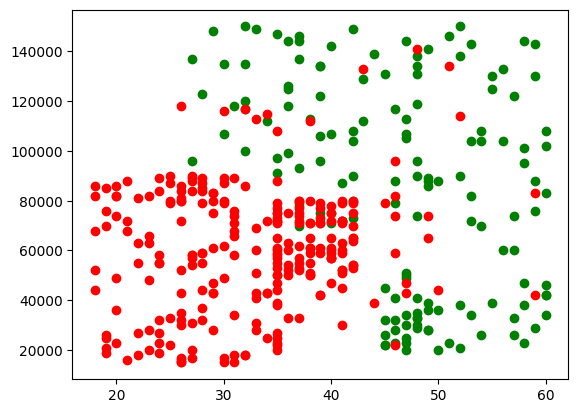

In [19]:
plt.scatter(purchased_data["Age"],purchased_data["EstimatedSalary"],c="green")
plt.scatter(not_purchased_data["Age"],not_purchased_data["EstimatedSalary"],c="red")

In [20]:
df['EstimatedSalary'].max()

np.int64(150000)

In [21]:
df['EstimatedSalary'].min()


np.int64(15000)

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ["Age","EstimatedSalary"]
scaled_values = scaler.fit_transform(df[features_to_scale])
df["norm_Age"] = scaled_values[:,0]
df["norm_Salary"] = scaled_values[:,1]
df.head()

,Age,EstimatedSalary,Purchased,norm_Age,norm_Salary
0,19,19000,0,0.023810,0.029630
1,35,20000,0,0.404762,0.037037
2,26,43000,0,0.190476,0.207407
3,27,57000,0,0.214286,0.311111
4,19,76000,0,0.023810,0.451852


In [24]:
from sklearn.model_selection import train_test_split

X=df[['norm_Age','norm_Salary']]
y=df['Purchased']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)

In [25]:
from sklearn.neighbors import KNeighborsClassifier
#knn with k = 5
model = KNeighborsClassifier(n_neighbors=5,metric="euclidean")
model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [26]:
model.score(X_train,y_train) * 100

93.75

In [27]:
model.score(X_test,y_test) * 100

90.0

2. Apply suitable Regression.

Read computer.csv dataset. Find no. of columns and rows with given dataset. Which regression model fit with given dataset? Build suitable regression model with the data and fetch intercept and coefficient. Visualize Models using pyplot. Compute the Coefficient of Determination to find accuracy.

In [4]:
computers = pd.read_csv("./data/computers.csv")

In [52]:
computers.head()

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74


In [53]:
computers.describe()

,Units,Minutes
count,14.000000,14.000000
mean,6.000000,97.214286
std,2.961289,46.217177
min,1.000000,23.000000
25%,4.000000,66.500000
50%,6.000000,96.500000
75%,8.750000,138.500000
max,10.000000,166.000000


In [54]:
computers.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Units    14 non-null     int64
 1   Minutes  14 non-null     int64
dtypes: int64(2)
memory usage: 356.0 bytes


In [58]:
computers.head(14)

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74
5,5,87
6,6,96
7,6,97
8,7,109
9,8,119


In [81]:
computers.columns

Index(['Units', 'Minutes'], dtype='str')

In [5]:
print("Number of Rows:", computers.shape[0])
print("Number of Columns:", computers.shape[1])

Number of Rows: 14
Number of Columns: 2


In [6]:
X = computers[['Units']]
y = computers['Minutes']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 2.1100478468899553
Coefficients: [15.92105263]


In [12]:
y_pred = model.predict(X_test)

0.98369617084431


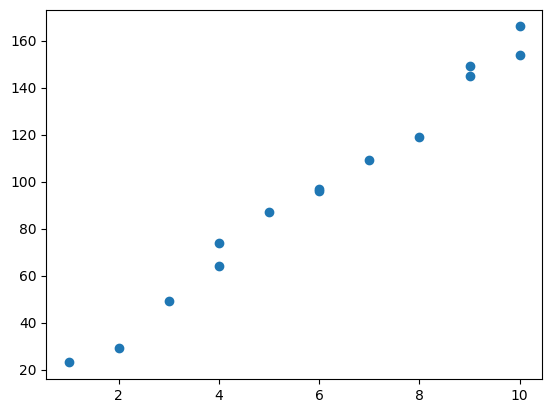

In [15]:
plt.scatter(X, y)
print(model.score(X_test, y_test))


In [16]:
r2 = r2_score(y_test, y_pred)

print("Coefficient of Determination (R²):", r2)


NameError: name 'r2_score' is not defined

In [94]:
from sklearn.metrics import r2_score

In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


R2 Score: 0.98369617084431
